# Cell Voltage Exploratory Data Analysis
**Date:** 2026-03-27 | **Runs:** 4 | **Pack:** 84-cell

## Summary
Pack behavior reveals significant cell imbalance driven by a small number of identifiable
weak cells, with an active P0A80 fault and DCL throttling confirmed at the pack level.
See conclusions for details.

**Imports & configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bms_utils as B

B.apply_lsu_style()

PATHS = sorted([
    '../data/raw/cellvoltages_2026-03-27-18-51-29.csv',
    '../data/raw/cellvoltages_2026-03-27-19-01-44.csv',
    '../data/raw/cellvoltages_2026-03-27-19-03-55.csv',
    '../data/raw/cellvoltages_2026-03-27-19-14-37.csv',
])

**Load runs**

Each run is loaded via `bms_utils.load_session` and tagged with a `run_id`. An
`elapsed_m` axis is built with a 1-second separator between runs so plots stay
monotonic; the real inter-run gaps (~10 / ~2 / ~11 min) are preserved in the
`Time` column and printed below.

In [2]:
runs = []
cumulative_offset_m = 0.0
for i, path in enumerate(PATHS):
    raw = B.load_session(path)
    raw['run_id'] = f'run_{i + 1:03d}'
    local_m = raw['elapsed_s'] / 60
    raw['elapsed_m'] = local_m + cumulative_offset_m
    cumulative_offset_m = raw['elapsed_m'].iloc[-1] + (1 / 60)  # ~1s plotting gap
    runs.append(raw)

df = pd.concat(runs, ignore_index=True)

# Real inter-run gaps from wall-clock timestamps
print('Inter-run gaps (real wall-clock):')
for a, b in zip(runs, runs[1:]):
    gap = (b['Time'].iloc[0] - a['Time'].iloc[-1]).total_seconds() / 60
    print(f'  {a["run_id"].iat[0]} → {b["run_id"].iat[0]}: {gap:.1f} min')
print()
print(df.isnull().sum().sum(), 'total missing values')

Inter-run gaps (real wall-clock):
  run_001 → run_002: 0.5 min
  run_002 → run_003: 1.6 min
  run_003 → run_004: 0.2 min

0 total missing values


**Pack data overview**

In [3]:
print(f'Session duration (plot axis): {df["elapsed_m"].max():.1f} min')
print(f'Total rows: {len(df)}')
for run, g in df.groupby('run_id'):
    print(f'  {run}: {len(g)} rows, {(g["elapsed_m"].max() - g["elapsed_m"].min()):.1f} min')
df.head()

Session duration (plot axis): 27.0 min
Total rows: 2816
  run_001: 522 rows, 9.7 min
  run_002: 53 rows, 0.6 min
  run_003: 1342 rows, 10.5 min
  run_004: 899 rows, 6.1 min


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Open Cell Voltage 79,Open Cell Voltage 80,Open Cell Voltage 81,Open Cell Voltage 82,Open Cell Voltage 83,Open Cell Voltage 84,elapsed_s,session_id,run_id,elapsed_m
0,2026-03-27 18:51:35,53.0,306.5,4.9,6,198,19,3.6962,31,3.5873,...,3.6470,3.6452,3.6463,3.6499,3.6459,3.6445,0.0,2026-03-27-18-51-29,run_001,0.000000
1,2026-03-27 18:51:36,53.0,306.6,4.7,6,198,19,3.6913,31,3.5865,...,3.6470,3.6452,3.6463,3.6499,3.6459,3.6445,1.0,2026-03-27-18-51-29,run_001,0.016667
2,2026-03-27 18:51:39,53.0,306.5,4.6,6,198,19,3.6948,31,3.5875,...,3.6470,3.6452,3.6463,3.6499,3.6459,3.6445,4.0,2026-03-27-18-51-29,run_001,0.066667
3,2026-03-27 18:51:39,53.0,306.5,4.6,6,198,19,3.6948,31,3.5875,...,3.6478,3.6460,3.6466,3.6500,3.6464,3.6458,4.0,2026-03-27-18-51-29,run_001,0.066667
4,2026-03-27 18:51:40,53.0,306.6,4.6,6,198,19,3.6887,31,3.5867,...,3.6478,3.6460,3.6466,3.6500,3.6464,3.6458,5.0,2026-03-27-18-51-29,run_001,0.083333


**Pack Current & Voltage Over Time**

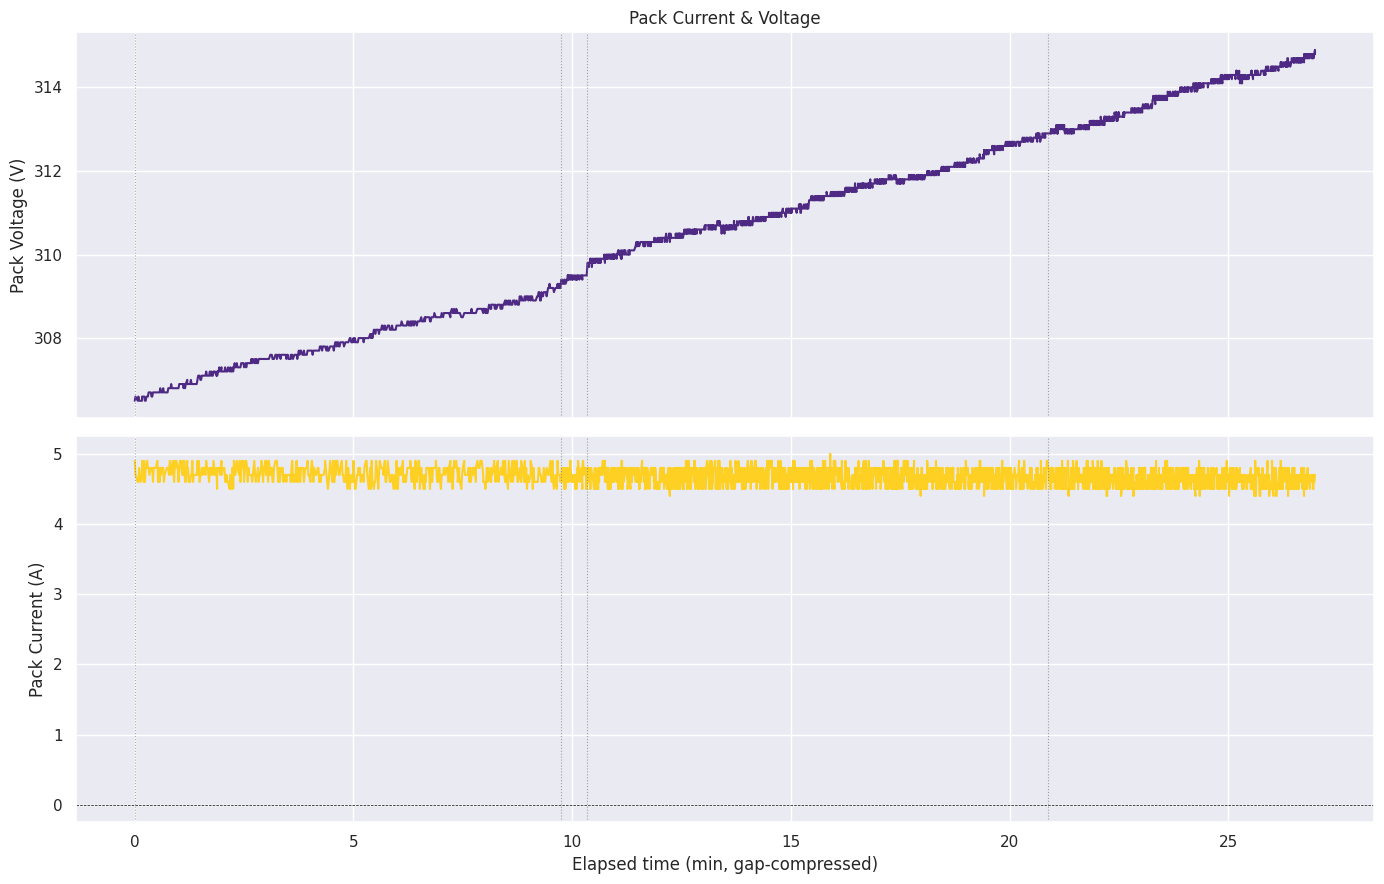

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['elapsed_m'], df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')
B.annotate_runs(axes[0], df)

axes[1].plot(df['elapsed_m'], df['Pack Current'], color='#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (A)')
axes[1].set_xlabel('Elapsed time (min, gap-compressed)')
B.annotate_runs(axes[1], df)

plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

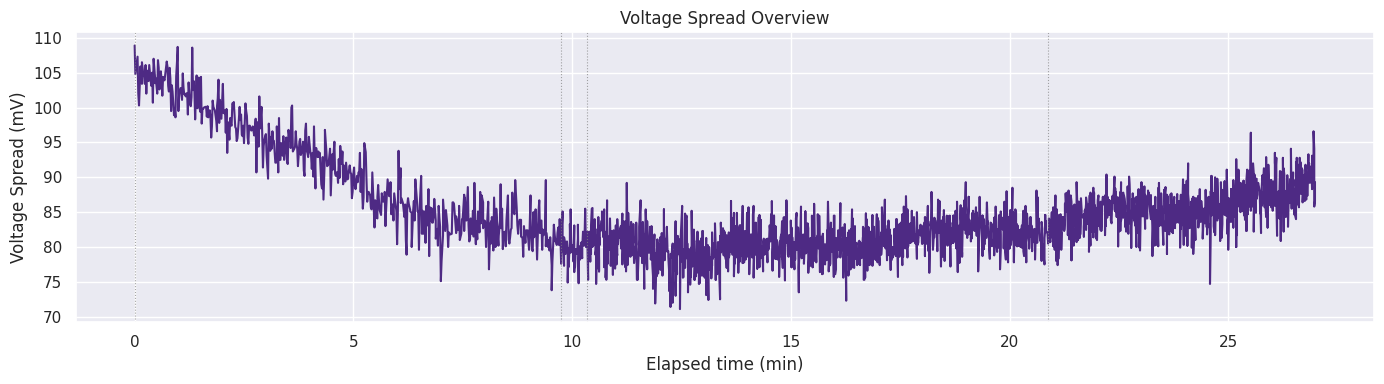

In [5]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (min)')
B.annotate_runs(ax, df)
plt.tight_layout()
plt.show()

**Pack Temperature & Spread**

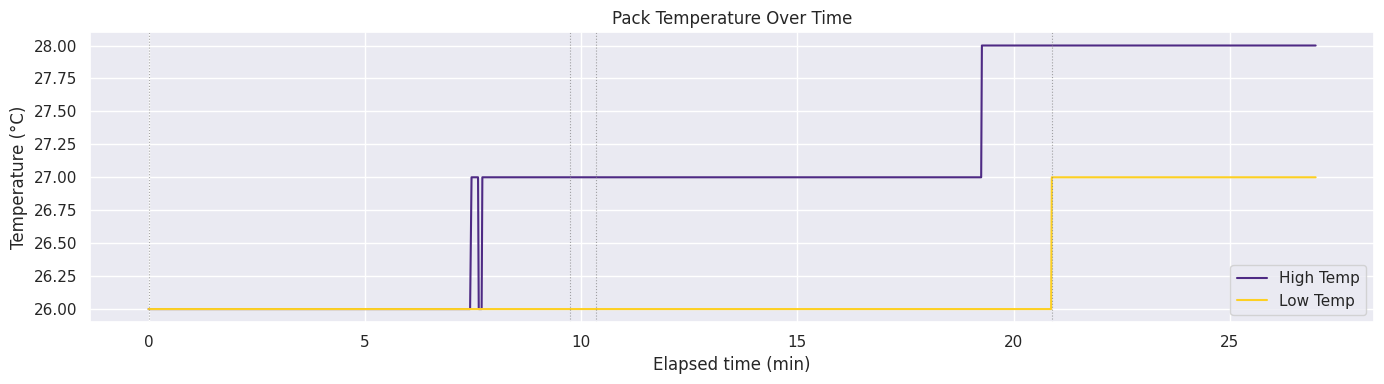

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_m'], df['High Temperature'], label='High Temp', color='#4E2A84')
ax.plot(df['elapsed_m'], df['Low Temperature'],  label='Low Temp',  color='#FDD023')
ax.set_title('Pack Temperature Over Time')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('Elapsed time (min)')
ax.legend()
B.annotate_runs(ax, df)
plt.tight_layout()
plt.show()

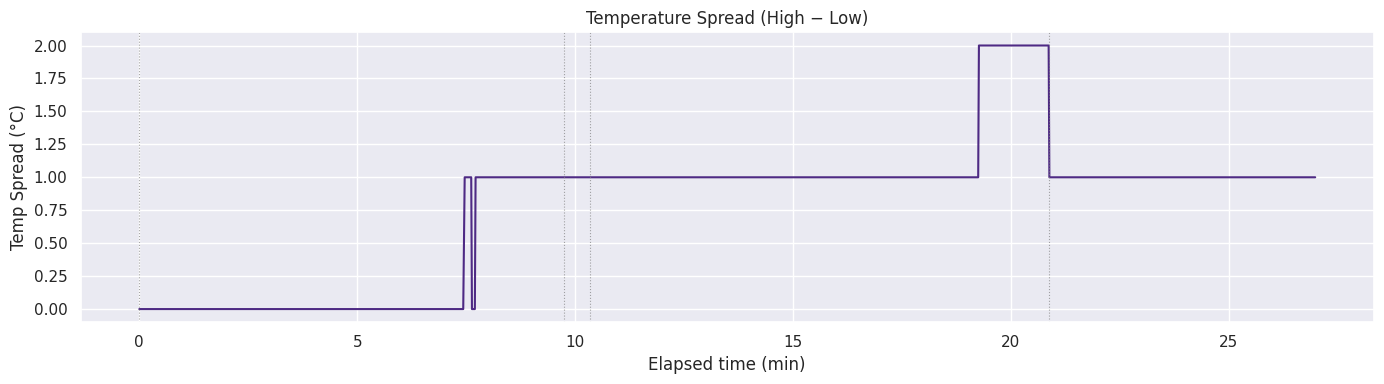

In [7]:
df['Temp Spread'] = df['High Temperature'] - df['Low Temperature']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_m'], df['Temp Spread'])
ax.set_title('Temperature Spread (High − Low)')
ax.set_ylabel('Temp Spread (°C)')
ax.set_xlabel('Elapsed time (min)')
B.annotate_runs(ax, df)
plt.tight_layout()
plt.show()

**Mean Voltage And Mean Rank Per Cell**

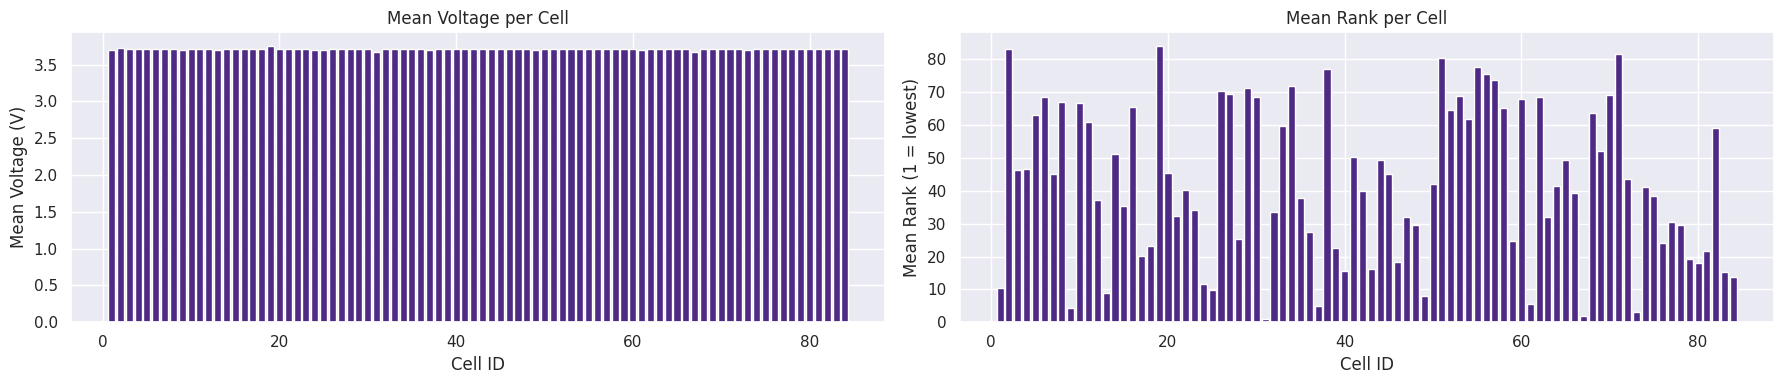

In [8]:
cell_mean_voltage = B.cell_mean_voltage(df)
cell_mean_rank = B.cell_mean_rank(df)
CELL_IDS = range(1, B.N_CELLS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
ax1.bar(CELL_IDS, cell_mean_voltage)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CELL_IDS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

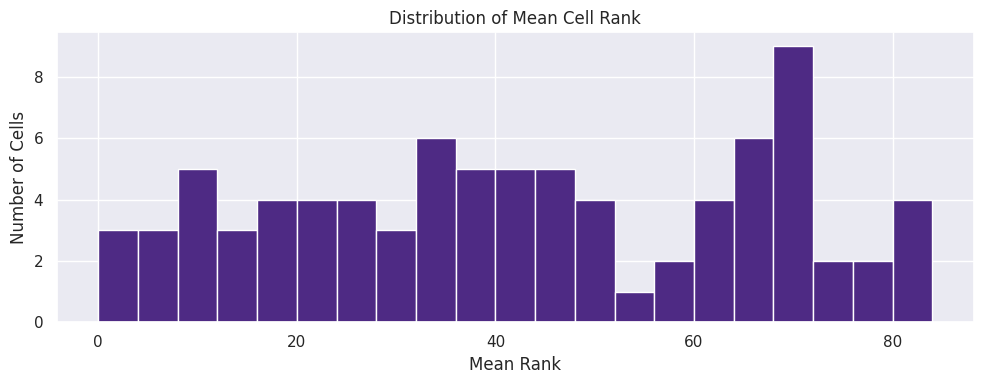

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')
plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score**

Most-below pack mean (z-score):
Cell Voltage 31   -4.737
Cell Voltage 67   -4.443
Cell Voltage 73   -1.226
Cell Voltage 9    -1.081
Cell Voltage 37   -0.924
dtype: float64

Most-above pack mean (z-score):
Cell Voltage 19    4.609
Cell Voltage 2     2.304
Cell Voltage 71    0.923
Cell Voltage 51    0.807
Cell Voltage 55    0.714
dtype: float64


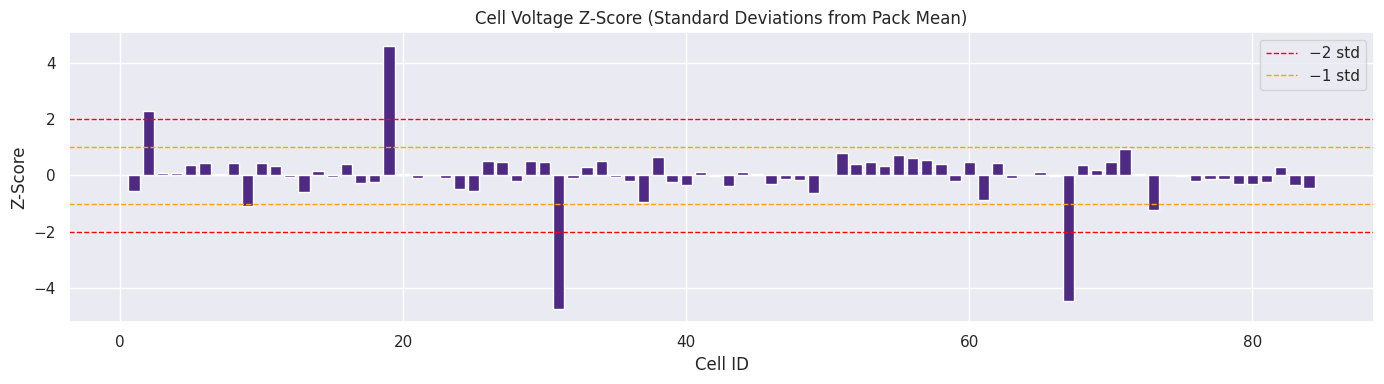

In [10]:
z_scores = B.cell_voltage_z(df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, B.N_CELLS + 1), z_scores)
ax.axhline(-2, color='red',    linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.axhline( 1, color='orange', linestyle='--', linewidth=1)
ax.axhline( 2, color='red',    linestyle='--', linewidth=1)
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()
plt.tight_layout()

print('Most-below pack mean (z-score):')
print(z_scores.nsmallest(5).round(3))
print('\nMost-above pack mean (z-score):')
print(z_scores.nlargest(5).round(3))
plt.show()

**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 31    3.6657
Cell Voltage 67    3.6683
Cell Voltage 73    3.6973
Cell Voltage 9     3.6986
Cell Voltage 37    3.7000
dtype: float64

Mean Rank of Weakest Cells (1-84)
Cell Voltage 31    1.03
Cell Voltage 67    1.97
Cell Voltage 73    3.26
Cell Voltage 9     4.28
Cell Voltage 37    5.07
dtype: float64

Mean Voltage of Strongest Cells (V)
Cell Voltage 19    3.7499
Cell Voltage 2     3.7291
Cell Voltage 71    3.7167
dtype: float64


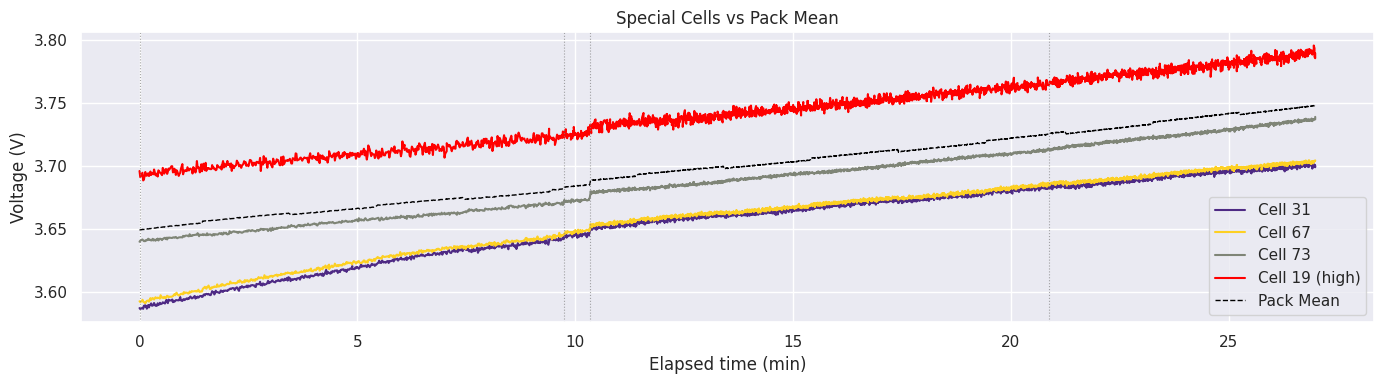

In [11]:
print('Mean Voltage of Weakest Cells (V)')
print(cell_mean_voltage.nsmallest(5).round(4))
print('\nMean Rank of Weakest Cells (1-84)')
print(cell_mean_rank.nsmallest(5).round(2))
print('\nMean Voltage of Strongest Cells (V)')
print(cell_mean_voltage.nlargest(3).round(4))

weak_cells  = z_scores.nsmallest(3).index.str.extract(r'(\d+)')[0].astype(int).tolist()
strong_cell = z_scores.nlargest(1).index.str.extract(r'(\d+)')[0].astype(int).tolist()

pack_mean = df[B.CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
for cell_id in weak_cells:
    ax.plot(df['elapsed_m'], df[f'Cell Voltage {cell_id}'], label=f'Cell {cell_id}')
for cell_id in strong_cell:
    ax.plot(df['elapsed_m'], df[f'Cell Voltage {cell_id}'],
            label=f'Cell {cell_id} (high)', color='red')
ax.plot(df['elapsed_m'], pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Voltage (V)')
ax.legend()
B.annotate_runs(ax, df)
plt.tight_layout()
plt.show()

**Load residual (V_loaded − OCV)**

Per-cell median voltage sag under load (`|Pack Current| ≥ 1 A`), in millivolts.
Computed from the previously-dropped Open Cell Voltage columns. Outliers here
indicate elevated internal resistance — the cell sags more than its peers at
the same pack current.

Largest |load residual| (mV):
2     1.3
4     1.2
10    1.2
3     1.2
18    1.2
5     1.2
8     1.2
6     1.2
Name: load_residual_mV, dtype: float64


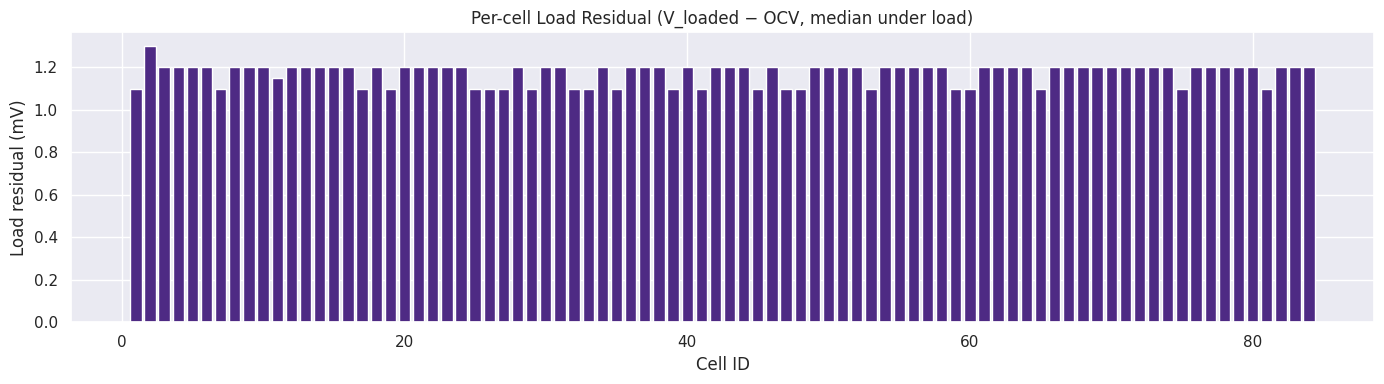

In [12]:
load_residual = B.load_residual_mv(df, min_abs_current_a=1.0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, B.N_CELLS + 1), load_residual.to_numpy())
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Per-cell Load Residual (V_loaded − OCV, median under load)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Load residual (mV)')
plt.tight_layout()

print('Largest |load residual| (mV):')
print(load_residual.reindex(load_residual.abs().sort_values(ascending=False).head(8).index).round(3))
plt.show()

## Conclusion

### Pack Health Overview
The pack charges with a narrowing voltage spread over time, opening at ~121 mV at
53% SOC and converging to ~26 mV by 66% SOC, indicating the balancer is active
and functional. However, the spread at session start is large enough to have
triggered a P0A80 Weak Cell fault, and the BMS has reduced the discharge current
limit from 198 A to 100 A as a direct consequence. This is not a balancing lag;
it reflects genuine capacity loss in specific cells.

### Cell 31
Cell 31 registers ~−6.3 standard deviations from pack mean, the largest single-cell
outlier by a wide margin. Its voltage lags the pack throughout the entire session
and it is identified as the lowest cell in the resting fault snapshot (3.606 V
instantaneous, 3.593 V OCV). Cell 31 is the primary driver of the active P0A80
fault and the DCL reduction. It should be escalated to senior team members for
physical inspection and replacement immediately.

### Cell 67
Cell 67 registers ~−4.5 standard deviations from pack mean and follows the same
lagging pattern as Cell 31 throughout the session. Its OCV of 3.570 V is 11 mV
below pack average at rest. It is a confirmed secondary fault contributor and
should be replaced alongside Cell 31.

### Cell 9
Cell 9 registers ~−2.7 standard deviations from pack mean and has an OCV of
3.557 V, which is 24 mV below pack average at rest. While it does not appear as
a dominant outlier in the live charge data, the resting OCV value places it
among the weakest cells in the pack. It warrants close monitoring in future sessions.

### Cells 10, 16, 30, 34, 52, 58
These cells do not stand out significantly in the time-series z-score analysis
but each registers at least 20 mV below pack average in the resting OCV data
from the fault snapshot. This divergence between live and resting readings is
characteristic of cells whose weakness is masked by IR effects during charging.
They cannot be meaningfully evaluated from charge logs alone and should be
re-examined in future fault snapshots.

### Notes & Next Steps
**Note:** The fault snapshot (BMS_FAULT.csv) is a more reliable health document
than this time-series log for identifying weak cells, as resting OCV and internal
resistance are unaffected by charge current. The two data sources should be read
together: the charge log shows how the pack behaves under load, and the fault
snapshot shows what the cells actually are at rest.

**Next steps:** Replace cells 31 and 67 before next track use, as the DCL
throttling they are causing directly limits vehicle performance. Investigate the
cell 2/3/4 module named in the fault subcodes. After replacement, capture a new
fault snapshot post-charge-to-rest to confirm P0A80 clears. Use `trends.ipynb`
to track whether cells 9, 10, 16, 30, 34, 52, and 58 continue to underperform
before taking further action.